In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
df_train = pd.read_csv('../input/titanic/train.csv')
df_test = pd.read_csv('../input/titanic/test.csv')

In [3]:
df_train.shape

(891, 12)

In [4]:
df_test.shape

(418, 11)

## 시각화

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set() # setting seaborn default for plots

In [6]:
# 사망자와 생존자별 막대그래프를 그려주는 함수를 정의
def bar_chart(feature):
    survived = df_train[df_train['Survived'] == 1][feature].value_counts()
    dead = df_train[df_train['Survived'] == 0][feature].value_counts()
    df = pd.DataFrame([survived, dead])
    df.index = ['Survived', 'Dead']
    df.plot(kind='bar', stacked=True, figsize=(10, 5))

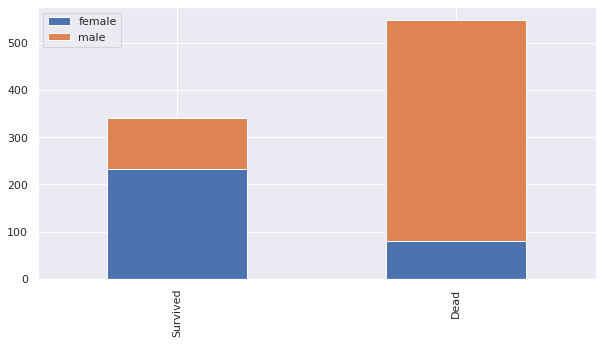

In [7]:
# 성별
bar_chart('Sex')

여성에 비해서 남성의 사망자 수가 더 많았다.

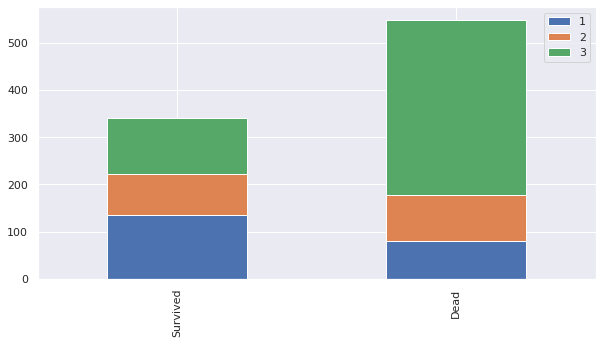

In [8]:
# 등급
bar_chart('Pclass')

사망자의 비율을 보면 3등급칸의 사람들이 훨씬 더 많이 사망했다.

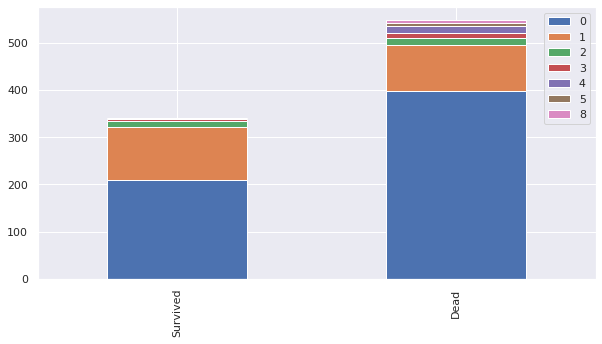

In [9]:
# 가족의 수
bar_chart('SibSp')

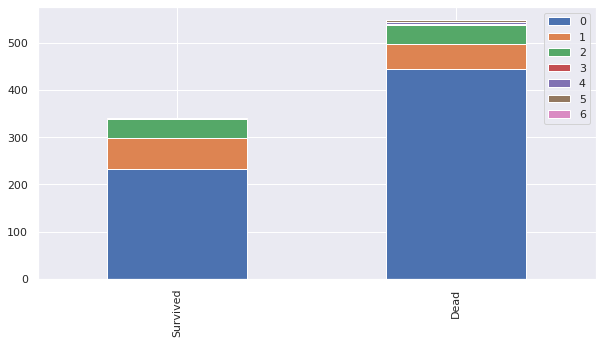

In [10]:
bar_chart('Parch')

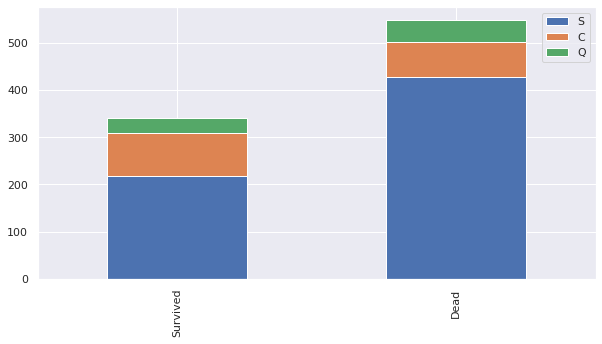

In [11]:
bar_chart('Embarked')

## Feature Engineering

### 이름

In [12]:
# 이름에서 호칭을 추출하기
train_test_data = [df_train, df_test]

for dataset in train_test_data:
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [13]:
df_train['Title'].value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64

In [14]:
df_test['Title'].value_counts()

Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: Title, dtype: int64

### 호칭을 숫자로 변경해서 컬럼을 생성한다.

In [15]:
# 딕셔너리로 맵핑할 데이터를 생성한다.
title_mapping = {'Mr': 0, 'Miss': 1, 'Mrs':2, 'Master': 3, 'Dr': 3, 'Rev': 3, 'Col': 3,
                 'Major': 3, 'Mlle': 3, 'Countess': 3, 'Ms': 3, 'Lady': 3, 'Jonkheer': 3, 
                 'Don': 3, 'Dona' : 3, 'Mme' : 3, 'Capt': 3, 'Sir': 3}
# 한 번에 변환한다.
for dataset in train_test_data:
    dataset['Title'] = dataset['Title'].map(title_mapping)

In [16]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [17]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,2


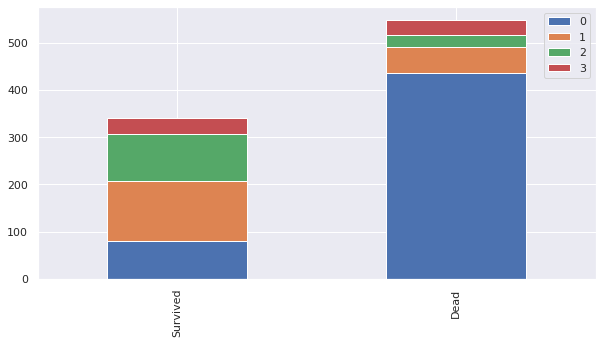

In [18]:
bar_chart('Title')

In [19]:
# delete unnecessary feature from dataset
df_train.drop('Name', axis=1, inplace=True)
df_test.drop('Name', axis=1, inplace=True)

In [20]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [21]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,female,22.0,1,1,3101298,12.2875,NaN,S,2


### 성별

In [22]:
sex_mapping = {'male': 0, 'female': 1}
for dataset in train_test_data:
    dataset['Sex'] = dataset['Sex'].map(sex_mapping)

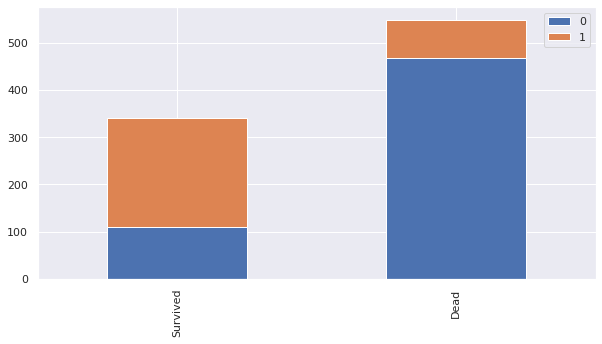

In [23]:
bar_chart('Sex')

### 나이

결측치는 호칭에 맞는 중앙값을 사용한다. 평균이나 중앙값을 사용한다.

In [24]:
# fill missing age with median age for each title
df_train['Age'].fillna(df_train.groupby('Title')['Age'].transform('median'), inplace=True)
df_test['Age'].fillna(df_test.groupby('Title')['Age'].transform('median'), inplace=True)

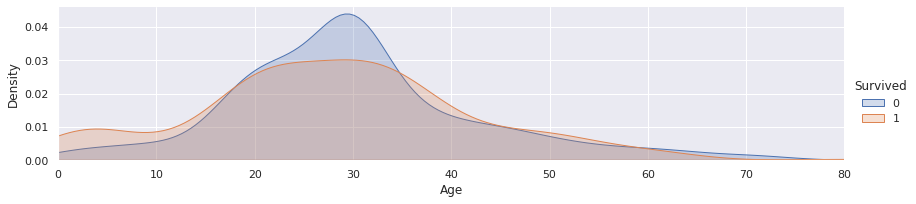

In [25]:
facet = sns.FacetGrid(df_train, hue='Survived', aspect=4)
facet.map(sns.kdeplot, 'Age', shade=True)
facet.set(xlim=(0, df_train['Age'].max()))
facet.add_legend()

plt.show()

(0.0, 20.0)

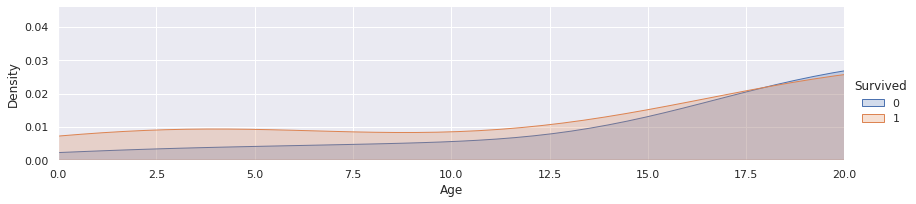

In [26]:
facet = sns.FacetGrid(df_train, hue='Survived', aspect=4)
facet.map(sns.kdeplot, 'Age', shade=True)
facet.set(xlim=(0, df_train['Age'].max()))
facet.add_legend()

plt.xlim(0, 20)

(20.0, 30.0)

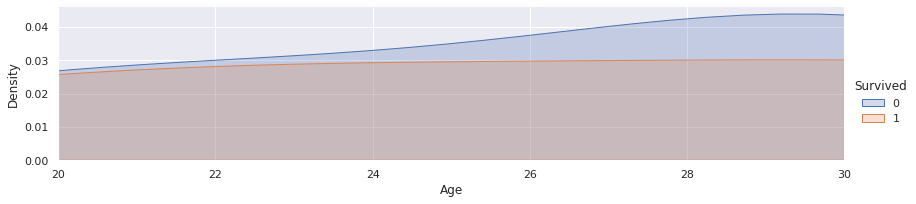

In [27]:
facet = sns.FacetGrid(df_train, hue='Survived', aspect=4)
facet.map(sns.kdeplot, 'Age', shade=True)
facet.set(xlim=(0, df_train['Age'].max()))
facet.add_legend()

plt.xlim(20, 30)

(30.0, 40.0)

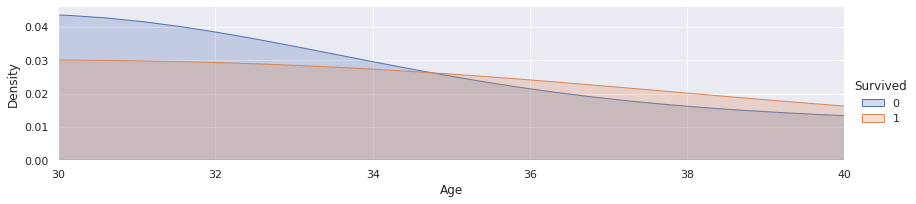

In [28]:
facet = sns.FacetGrid(df_train, hue='Survived', aspect=4)
facet.map(sns.kdeplot, 'Age', shade=True)
facet.set(xlim=(0, df_train['Age'].max()))
facet.add_legend()

plt.xlim(30, 40)

(40.0, 60.0)

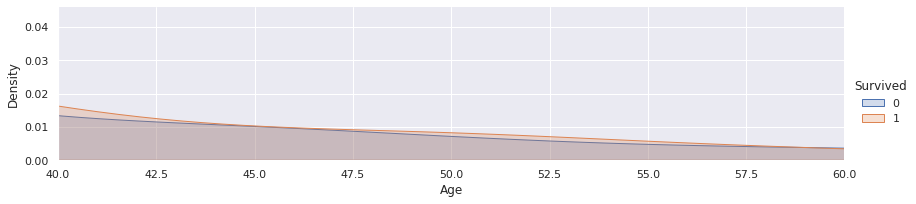

In [29]:
facet = sns.FacetGrid(df_train, hue='Survived', aspect=4)
facet.map(sns.kdeplot, 'Age', shade=True)
facet.set(xlim=(0, df_train['Age'].max()))
facet.add_legend()

plt.xlim(40, 60)

(60.0, 80.0)

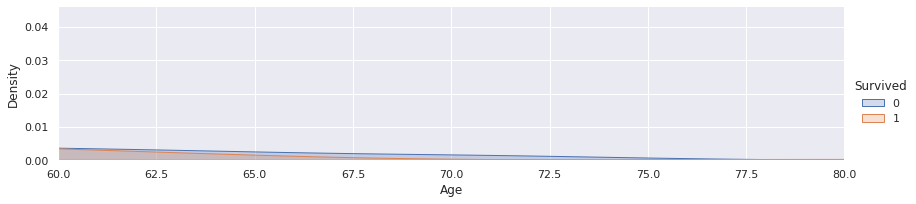

In [30]:
facet = sns.FacetGrid(df_train, hue='Survived', aspect=4)
facet.map(sns.kdeplot, 'Age', shade=True)
facet.set(xlim=(0, df_train['Age'].max()))
facet.add_legend()

plt.xlim(60)

In [31]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Title        891 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 83.7+ KB


In [32]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Fare         417 non-null    float64
 8   Cabin        91 non-null     object 
 9   Embarked     418 non-null    object 
 10  Title        418 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 36.0+ KB


### 비닝

In [33]:
# 나이의 범위에 따라 카테고리를 반환하는 함수
def category_age(x):
    if x < 17:
        return 0
    elif x < 27:
        return 1
    elif x < 37:
        return 2
    elif x < 63:
        return 3
    else:
        return 4

In [34]:
# 나이를 카테고리화 한다.
df_train['Age'] = df_train['Age'].apply(category_age)
df_test['Age'] = df_test['Age'].apply(category_age)

In [35]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,1,3,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,2,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,2,0,0,373450,8.0500,NaN,S,0


In [36]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,0,2,0,0,330911,7.8292,NaN,Q,0
1,893,3,1,3,1,0,363272,7.0000,NaN,S,2
2,894,2,0,3,0,0,240276,9.6875,NaN,Q,0
3,895,3,0,2,0,0,315154,8.6625,NaN,S,0
4,896,3,1,1,1,1,3101298,12.2875,NaN,S,2


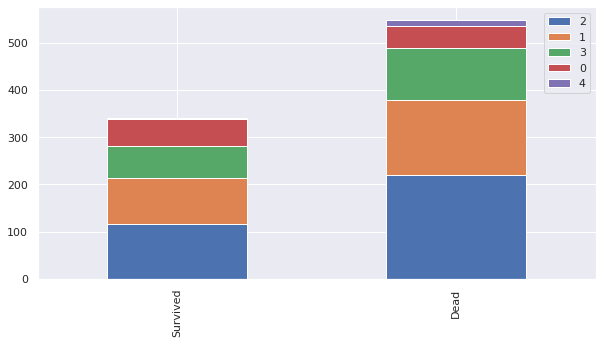

In [37]:
bar_chart('Age')

### 승선지

In [38]:
pd.crosstab(df_train['Embarked'], df_train['Pclass'], margins=True).T.style.background_gradient(cmap='Blues')

Embarked,C,Q,S,All
Pclass,,,,
1,85,2,127,214
2,17,3,164,184
3,66,72,353,491
All,168,77,644,889


- 승선지가 Q인 사람들은 93% 3등급 칸을 탔다. 
- C인 사람들은 2등급보다 1등급과 3등급에 상대적으로 많이 탔다.
- S는 3등급이 가장 많긴하지만 다른 클래스에서도 다수를 차지한다.

In [39]:
# 승선지 결측치 S로 변경
df_train['Embarked'].fillna('S', inplace=True)

In [40]:
# 승선지를 숫자로 변경한다.
embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
df_train['Embarked'] = df_train['Embarked'].map(embarked_mapping)
df_test['Embarked'] = df_test['Embarked'].map(embarked_mapping)

### 요금

테스트에 결측치가 하나 있다. 클래스의 중앙값으로 변경해준다.

In [41]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    int64  
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Fare         417 non-null    float64
 8   Cabin        91 non-null     object 
 9   Embarked     418 non-null    int64  
 10  Title        418 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 36.0+ KB


In [42]:
# 같은 클래스의 요금 중앙값으로 변경
df_test['Fare'].fillna(df_test.groupby('Pclass')['Fare'].transform('median'), inplace=True)

In [43]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    int64  
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Fare         418 non-null    float64
 8   Cabin        91 non-null     object 
 9   Embarked     418 non-null    int64  
 10  Title        418 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 36.0+ KB


In [44]:
df_train.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,1.712682,0.523008,0.381594,32.204208,0.361392,0.710438
std,257.353842,0.486592,0.836071,0.477990,0.971762,1.102743,0.806057,49.693429,0.635673,0.968778
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,7.910400,0.000000,0.000000
50%,446.000000,0.000000,3.000000,0.000000,2.000000,0.000000,0.000000,14.454200,0.000000,0.000000
75%,668.500000,1.000000,3.000000,1.000000,2.000000,1.000000,0.000000,31.000000,1.000000,1.000000
max,891.000000,1.000000,3.000000,1.000000,4.000000,8.000000,6.000000,512.329200,2.000000,3.000000


### 요금을 비닝한다. 

카테고리화 한다.

In [45]:
def category_fare(x):
    if x < 18:
        return 0
    elif x < 31:
        return 1
    elif x < 101:
        return 2
    else:
        return 3

In [46]:
df_train['Fare'] = df_train['Fare'].apply(category_fare)
df_test['Fare'] = df_test['Fare'].apply(category_fare)

In [47]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1,1,0,A/5 21171,0,NaN,0,0
1,2,1,1,1,3,1,0,PC 17599,2,C85,1,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,0,NaN,0,1
3,4,1,1,1,2,1,0,113803,2,C123,0,2
4,5,0,3,0,2,0,0,373450,0,NaN,0,0


In [48]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,0,2,0,0,330911,0,NaN,2,0
1,893,3,1,3,1,0,363272,0,NaN,0,2
2,894,2,0,3,0,0,240276,0,NaN,2,0
3,895,3,0,2,0,0,315154,0,NaN,0,0
4,896,3,1,1,1,1,3101298,0,NaN,0,2


## Cabin


In [49]:
df_train.Cabin.value_counts()

B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: Cabin, Length: 147, dtype: int64

In [50]:
# 첫번째 캐릭터만 남기고 숫자는 지운다.
df_train['Cabin'] = df_train['Cabin'].str[:1]
df_test['Cabin'] = df_test['Cabin'].str[:1]

In [51]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1,1,0,A/5 21171,0,NaN,0,0
1,2,1,1,1,3,1,0,PC 17599,2,C,1,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,0,NaN,0,1
3,4,1,1,1,2,1,0,113803,2,C,0,2
4,5,0,3,0,2,0,0,373450,0,NaN,0,0


In [52]:
df_test['Cabin'].value_counts()

C    35
B    18
D    13
E     9
F     8
A     7
G     1
Name: Cabin, dtype: int64

<AxesSubplot:>

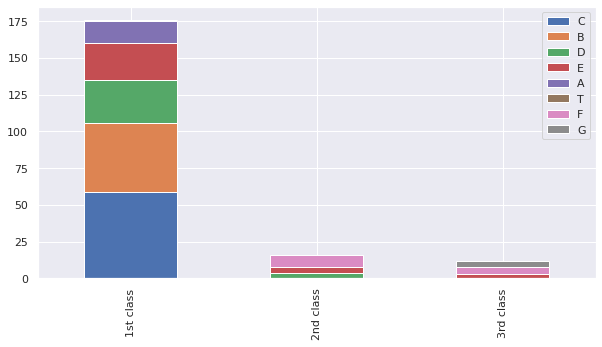

In [53]:
Pclass1 = df_train[df_train['Pclass']==1]['Cabin'].value_counts()
Pclass2 = df_train[df_train['Pclass']==2]['Cabin'].value_counts()
Pclass3 = df_train[df_train['Pclass']==3]['Cabin'].value_counts()
df = pd.DataFrame([Pclass1, Pclass2, Pclass3])
df.index = ['1st class', '2nd class', '3rd class']
df.plot(kind='bar', stacked=True, figsize=(10, 5))

In [54]:
pd.crosstab(df_train['Cabin'], df_train['Pclass'], margins=True).T.style.background_gradient(cmap='summer_r')

Cabin,A,B,C,D,E,F,G,T,All
Pclass,,,,,,,,,
1,15,47,59,29,25,0,0,1,176
2,0,0,0,4,4,8,0,0,16
3,0,0,0,0,3,5,4,0,12
All,15,47,59,33,32,13,4,1,204


등급별 캐빈을 보면 A,B,C,T는 2,3등급에는 없다. D,E도 대부분 1등급이다. F는 1등급에는 없고, G는 3등급에만 있다. 

In [55]:
# 등급별로 캐빈의 가중치를 설정해서 맵핑한다.
cabin_mapping = {'A': 0, 'T': 0, 'B': 0.4, 'C': 0.8, 'D': 1.2, 'E': 1.6, 'F': 2, 'G': 2.4}
df_train['Cabin'] = df_train['Cabin'].map(cabin_mapping)
df_test['Cabin'] = df_test['Cabin'].map(cabin_mapping)

In [56]:
# 캐빈의 결측치 채우기
df_train['Cabin'].fillna(df_train.groupby('Pclass')['Cabin'].transform('median'), inplace=True)
df_test['Cabin'].fillna(df_test.groupby('Pclass')['Cabin'].transform('median'), inplace=True)

In [57]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    int64  
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    int64  
 9   Cabin        891 non-null    float64
 10  Embarked     891 non-null    int64  
 11  Title        891 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 83.7+ KB


In [58]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    int64  
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Fare         418 non-null    int64  
 8   Cabin        418 non-null    float64
 9   Embarked     418 non-null    int64  
 10  Title        418 non-null    int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 36.0+ KB


이제 결측치는 없다!

## 가족 컬럼 생성

In [59]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1,1,0,A/5 21171,0,2.0,0,0
1,2,1,1,1,3,1,0,PC 17599,2,0.8,1,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,0,2.0,0,1
3,4,1,1,1,2,1,0,113803,2,0.8,0,2
4,5,0,3,0,2,0,0,373450,0,2.0,0,0


In [60]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1

In [61]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,0,1,1,0,A/5 21171,0,2.0,0,0,2
1,2,1,1,1,3,1,0,PC 17599,2,0.8,1,2,2
2,3,1,3,1,1,0,0,STON/O2. 3101282,0,2.0,0,1,1
3,4,1,1,1,2,1,0,113803,2,0.8,0,2,2
4,5,0,3,0,2,0,0,373450,0,2.0,0,0,1


### 가족 수 별 사망률 확인하기

In [62]:
pd.crosstab(df_train['FamilySize'], df_train['Survived'], margins=True).T.style.background_gradient(cmap='summer_r')

FamilySize,1,2,3,4,5,6,7,8,11,All
Survived,,,,,,,,,,
0,374,72,43,8,12,19,8,6,7,549
1,163,89,59,21,3,3,4,0,0,342
All,537,161,102,29,15,22,12,6,7,891


In [63]:
for i in df_train['FamilySize'].unique():
#     print('동승인 {}명의 사망률 {:.1f}%'.format(i-1, 100 * df_train[(df_train['FamilySize'] == i) & (df_train['Survived'] == 0)].shape[0] / df_train[df_train['FamilySize'] == i].shape[0]))
    print('가족수 {}명의 생존률 {:.1f}%'.format(i, 100 * df_train[(df_train['FamilySize'] == i) & (df_train['Survived'] == 1)].shape[0] / df_train[df_train['FamilySize'] == i].shape[0]))

가족수 2명의 생존률 55.3%
가족수 1명의 생존률 30.4%
가족수 5명의 생존률 20.0%
가족수 3명의 생존률 57.8%
가족수 7명의 생존률 33.3%
가족수 6명의 생존률 13.6%
가족수 4명의 생존률 72.4%
가족수 8명의 생존률 0.0%
가족수 11명의 생존률 0.0%


In [64]:
family_mapping = {8: 0, 11: 0, 9: 0, 10: 0, 6: 0.4, 5: 0.8, 1: 1.2, 7: 1.6, 2: 2, 3: 2.4, 4: 2.8}
df_train['FamilySize'] = df_train['FamilySize'].map(family_mapping)
df_test['FamilySize'] = df_test['FamilySize'].map(family_mapping)

In [65]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,0,1,1,0,A/5 21171,0,2.0,0,0,2.0
1,2,1,1,1,3,1,0,PC 17599,2,0.8,1,2,2.0
2,3,1,3,1,1,0,0,STON/O2. 3101282,0,2.0,0,1,1.2
3,4,1,1,1,2,1,0,113803,2,0.8,0,2,2.0
4,5,0,3,0,2,0,0,373450,0,2.0,0,0,1.2


In [66]:
df_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,892,3,0,2,0,0,330911,0,2.0,2,0,1.2
1,893,3,1,3,1,0,363272,0,2.0,0,2,2.0
2,894,2,0,3,0,0,240276,0,2.0,2,0,1.2
3,895,3,0,2,0,0,315154,0,2.0,0,0,1.2
4,896,3,1,1,1,1,3101298,0,2.0,0,2,2.4


In [67]:
# 티켓의 첫번째 캐릭터만 남기고 지운다.
df_train['Ticket'] = df_train['Ticket'].str[:1]
df_test['Ticket'] = df_test['Ticket'].str[:1]

In [68]:
pd.crosstab(df_train['Ticket'], df_train['Pclass'], margins=True).T.style.background_gradient(cmap='summer_r')

Ticket,1,2,3,4,5,6,7,8,9,A,C,F,L,P,S,W,All
Pclass,,,,,,,,,,,,,,,,,
1,131,4,14,0,1,2,0,0,0,0,0,1,0,60,0,3,216
2,3,119,5,0,0,0,0,0,0,0,20,5,0,2,27,3,184
3,12,60,282,10,2,4,9,2,1,29,27,1,4,3,38,7,491
All,146,183,301,10,3,6,9,2,1,29,47,7,4,65,65,13,891


In [69]:
df_train['Ticket'][3]

'1'

In [70]:
ticket_mapping = {'1': 0, 'P': 0.4, '2': 0.8, 'C': 1.2, 'S': 1.6, 'F': 1.6, '3': 2, '4': 2, '5': 2, '6': 2, '7': 2, '8': 2, '9': 2 ,'A': 2, 'L': 2.4 ,'W': 2.4}
df_train['Ticket'] = df_train['Ticket'].map(ticket_mapping)
df_test['Ticket'] = df_test['Ticket'].map(ticket_mapping)

In [71]:
df_train['Ticket'].value_counts()

2.0    361
0.8    183
0.0    146
1.6     72
0.4     65
1.2     47
2.4     17
Name: Ticket, dtype: int64

In [72]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,0,1,1,0,2.0,0,2.0,0,0,2.0
1,2,1,1,1,3,1,0,0.4,2,0.8,1,2,2.0
2,3,1,3,1,1,0,0,1.6,0,2.0,0,1,1.2
3,4,1,1,1,2,1,0,0.0,2,0.8,0,2,2.0
4,5,0,3,0,2,0,0,2.0,0,2.0,0,0,1.2


In [73]:
df_train.drop(['PassengerId','SibSp', 'Parch'], axis=1, inplace=True)
df_test.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [74]:
df_train.head()

,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,0,1,2.0,0,2.0,0,0,2.0
1,1,1,1,3,0.4,2,0.8,1,2,2.0
2,1,3,1,1,1.6,0,2.0,0,1,1.2
3,1,1,1,2,0.0,2,0.8,0,2,2.0
4,0,3,0,2,2.0,0,2.0,0,0,1.2


In [75]:
df_test.head()

,PassengerId,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,892,3,0,2,2.0,0,2.0,2,0,1.2
1,893,3,1,3,2.0,0,2.0,0,2,2.0
2,894,2,0,3,0.8,0,2.0,2,0,1.2
3,895,3,0,2,2.0,0,2.0,0,0,1.2
4,896,3,1,1,2.0,0,2.0,0,2,2.4


In [76]:
X_train = df_train.drop('Survived', axis=1)
target_label = df_train['Survived']

## 모델 생성

In [77]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)

### KNN

In [78]:
clf = KNeighborsClassifier(n_neighbors = 13)
scoring = 'accuracy'
score = cross_val_score(clf, X_train, target_label, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.78888889 0.7752809  0.79775281 0.80898876 0.83146067 0.82022472
 0.79775281 0.80898876 0.80898876 0.83146067]


In [79]:
round(np.mean(score)*100, 2)

80.7

### Decision Tree

In [80]:
clf = DecisionTreeClassifier()
scoring = 'accuracy'
score = cross_val_score(clf, X_train, target_label, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.78888889 0.83146067 0.76404494 0.78651685 0.84269663 0.7752809
 0.84269663 0.82022472 0.75280899 0.84269663]


In [81]:
round(np.mean(score)*100, 2)

80.47

### Naiv Bayes

In [82]:
clf = GaussianNB()
scoring = 'accuracy'
score = cross_val_score(clf, X_train, target_label, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.78888889 0.7752809  0.75280899 0.68539326 0.75280899 0.82022472
 0.73033708 0.71910112 0.82022472 0.71910112]


In [83]:
round(np.mean(score)*100, 2)

75.64

### SVM

In [84]:
clf = SVC()
scoring = 'accuracy'
score = cross_val_score(clf, X_train, target_label, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.83333333 0.79775281 0.83146067 0.82022472 0.84269663 0.80898876
 0.83146067 0.85393258 0.83146067 0.84269663]


In [85]:
round(np.mean(score)*100, 2)

82.94

## Testing

In [86]:
clf = SVC()
clf.fit(X_train, target_label)

test_data = df_test.drop('PassengerId', axis=1).copy()
prediction = clf.predict(test_data)

In [87]:
# submission = pd.DataFrame({
#     'PassengerId': df_test['PassengerId'],
#     'Survived': prediction
# })
# submission.to_csv('submission.csv', index=False)

In [88]:
submission = pd.read_csv('../input/titanic/gender_submission.csv')

In [89]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [90]:
submission['Survived'] = prediction

In [91]:
submission.to_csv('./my_first_submission_titanic.csv', index=False)